## LEC 2 - Maths & numpy

In [ ]:
# derivative

import torch
x = torch.tensor(2.0, requires_grad = True)
y = x**2

y.backward()
print(x.grad)

tensor(4.)


In [ ]:

import numpy as np

a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])

# Addition: add element by element
print(a + b)      # [5. 7. 9.]

# Scalar multiplication: multiply every element by 2
print(2 * a)      # [2. 4. 6.]


[5. 7. 9.]
[2. 4. 6.]


In [ ]:
import torch
import torch.nn as nn

# Build the model
deep = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

# Create fake data — 32 students, 10 features each
X = torch.randn(32, 10)   # random numbers, just to test shape

# Pass through model
output = deep(X)

print(output.shape)   # torch.Size([32, 1])
print(output[:5])     # first 5 students' predicted scores

torch.Size([32, 1])
tensor([[ 0.0506],
        [-0.1013],
        [-0.0644],
        [ 0.0303],
        [-0.0622]], grad_fn=<SliceBackward0>)


In [ ]:
import numpy as np

# Simulate one neural network layer
# 3 examples, each with 4 input features
X = np.array([[1,2,3,4],
              [5,6,7,8],
              [9,10,11,12]])   # shape: (3, 4)
print(X)
# Weight matrix: 4 inputs → 2 outputs
W = np.random.randn(4, 2)      # shape: (4, 2)
print(W)
# Forward pass: multiply X by W
output = X @ W                 # shape: (3, 2)
print(output.shape)            # (3, 2) — 3 examples, 2 outputs each


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
[[-0.66840689 -1.11515262]
 [ 0.49718382  0.85014146]
 [-0.28496249  2.09422514]
 [ 0.24156087  0.94822037]]
(3, 2)


In [ ]:
#  Mean, median, mode with numpy and scipy
import numpy as np
from scipy import stats

data = np.array([2, 4, 4, 4, 5, 5, 7, 9])

print('Mean:  ', np.mean(data))    # 5.0
print('Median:', np.median(data))  # 4.5
print('Mode:  ', stats.mode(data).mode)  # 4



Mean:   5.0
Median: 4.5
Mode:   4


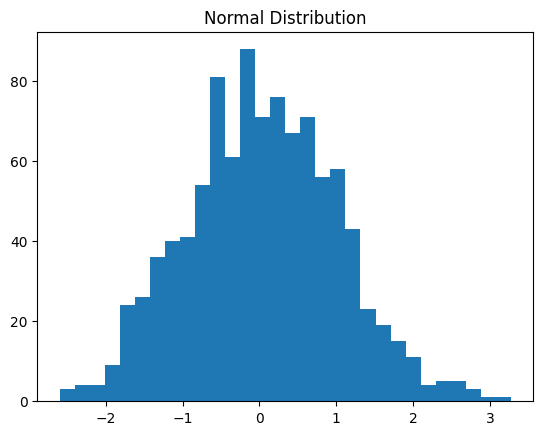

In [ ]:
  # Sampling from a normal distribution
import numpy as np
import matplotlib.pyplot as plt

# Generate 1000 values from N(mean=0, std=1)
data = np.random.normal(loc=0, scale=1, size=1000)

plt.hist(data, bins=30)
plt.title('Normal Distribution')
plt.show()


In [ ]:
# bayes practical

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

emails = ["Win FREE money now", "Meeting at 3pm", "FREE prize claim"]
labels = [1, 0, 1] # 1=spam, 0=legit

vec = CountVectorizer()
X = vec.fit_transform(emails) # words → numbers

model = MultinomialNB()
model.fit(X, labels)

new = vec.transform(["Claim your FREE gift"])
print(model.predict(new)) # [1] → spam

In [ ]:
# Simple gradient descent from scratch
# Find the minimum of f(x) = x^2 using gradient descent
x = 10.0          # start far from the minimum (minimum is at x=0)
lr = 0.1          # learning rate

for step in range(20):
    gradient = 2 * x    # derivative of x^2 is 2x
    x = x - lr * gradient  # move in the opposite direction of gradient
    print(f'Step {step+1}: x = {x:.4f}')


Step 1: x = 8.0000
Step 2: x = 6.4000
Step 3: x = 5.1200
Step 4: x = 4.0960
Step 5: x = 3.2768
Step 6: x = 2.6214
Step 7: x = 2.0972
Step 8: x = 1.6777
Step 9: x = 1.3422
Step 10: x = 1.0737
Step 11: x = 0.8590
Step 12: x = 0.6872
Step 13: x = 0.5498
Step 14: x = 0.4398
Step 15: x = 0.3518
Step 16: x = 0.2815
Step 17: x = 0.2252
Step 18: x = 0.1801
Step 19: x = 0.1441
Step 20: x = 0.1153


In [ ]:
#  StandardScaler — the standard choice for AI models
from sklearn.preprocessing import StandardScaler
import numpy as np

X = np.array([[20000], [40000], [60000], [80000], [100000]])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)   # values around 0, roughly between -2 and 2


[[-1.41421356]
 [-0.70710678]
 [ 0.        ]
 [ 0.70710678]
 [ 1.41421356]]


In [ ]:
# bias
weight = 10     # each extra hour adds 10 marks
bias   = 30     # even 0 hours → you still score 30 (baseline)

hours = 5
score = weight * hours + bias
# score = 10×5 + 30 = 80

In [ ]:
import numpy as np

matrix = np.array([[1,2,3],
                   [4,5,6],
                   [7,8,9]])

row_bias = np.array([10, 20, 30])

# Add row_bias to EVERY ROW of matrix (broadcasting)
result = matrix + row_bias
print(result)


[[11 22 33]
 [14 25 36]
 [17 28 39]]


In [ ]:
mask = np.ones((32,))   # start with all 1s — include everyone
mask[5] = 0             # change student 5 to 0 — exclude them
output = output * mask  # multiply: everyone×1=same, student5×0=gone

# You didn't delete anything. The array still has 32 rows. Student 5's values just became zero, so they have no effect on whatever you calculate next.


The 4 steps every neural network does, always:
1. FORWARD  →  make a prediction with current weights
2. LOSS     →  measure how wrong the prediction was
3. BACKWARD →  figure out which weights caused the error
4. UPDATE   →  nudge weights to be less wrong next time

small neural network for maths lecture

In [ ]:
# step 1

import numpy as np

X = np.random.randn(5,3) #random 5 studnets with 3 features

y = np.array([1,0,1,0,1]) #true labels,  binary classification as 1 is pass ,0 is fail

print(y)
print(X)




[1 0 1 0 1]
[[ 1.86387945  0.02313697  0.99952847]
 [ 0.26989378 -0.15560236  0.25894722]
 [ 1.29488158 -0.90831845 -1.55860555]
 [ 1.20108073  0.25748878  2.01270765]
 [ 0.25118201  0.65768046  0.91871617]]


In [ ]:
W = np.random.randn(3,1)*0.01 # keep the weights low by 0.01
b = np.zeros((1,))  #need one dimensional array for bias for matrix

# forward pass
z = X @ W + b

# npw we got raw score , covert into sigmoid to get probabilit of student passing
sigmoid = lambda x:1 /(1 +np.exp(-x))   #x is some input, this is just a function, it really mean e with -z, for e we take numpy fucntion.

prediction = sigmoid(z) # this gets us each value between 0-1

print(prediction)




[[0.50063538]
 [0.49812727]
 [0.50222318]
 [0.49967341]
 [0.49869442]]


In [ ]:
# getting loss and gradient
# binary cross entropy loss

y = y.reshape(5, 1)     # make y same shape as predictions
loss = -np.mean(y * np.log(prediction) + (1-y) * np.log(1-prediction))
print('Loss:', loss)

# Gradient of loss w.r.t. weights (derived using chain rule)
dW = (1/5) * X.T @ (prediction- y)
db = np.mean(prediction - y)

# Update weights (one gradient descent step)
W = W - 0.1 * dW
b = b - 0.1 * db


Loss: 0.6916505197605931


In [ ]:
loss = criterion(predictions, y)   # BCE loss — one line
loss.backward()                    # computes ALL gradients automatically
optimizer.step()                   # updates ALL weights automatically

same thing without maths/ FIRST NEURAL NETWORK

In [ ]:
#same thing with torch
import torch
import torch.nn as nn

# ── Step 1: Data ──────────────────────────────────────────
X = torch.randn(5, 3)                          # same as np.random.randn(5, 3)
y = torch.tensor([1, 0, 1, 0, 1], dtype=torch.float32).reshape(5, 1)  #craete two y

# ── Step 2: Define the model ──────────────────────────────
model = nn.Sequential(
    nn.Linear(3, 1),    # replaces: W = randn(3,1)*0.01, b = zeros(1,), z = X@W+b
    nn.Sigmoid()        # replaces: sigmoid = lambda x: 1/(1+np.exp(-x))
)

# ── Step 3: Loss function and optimiser ───────────────────
criterion = nn.BCELoss()                       # replaces: your manual BCE formula
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)  # replaces: W = W - 0.1*dW

# ── Step 4: One training step ─────────────────────────────
predictions = model(X)                         # forward pass
loss = criterion(predictions, y)               # compute loss
loss.backward()                                # replaces: dW = (1/5)*X.T@(predictions-y)
optimizer.step()                               # replaces: W = W - 0.1*dW

print('Loss:', loss.item())

Loss: 1.066589117050171


# LEC 3- Python for AI

NUMPY

In [ ]:
import numpy as np

# From a Python list
a = np.array([1, 2, 3, 4, 5])

# Array of zeros — common for initialising weight matrices
zeros = np.zeros((3, 4))      # 3 rows, 4 columns, all zeros
print(zeros)
# Array of ones
ones = np.ones((2, 3))
print(ones)
# Identity matrix — useful in linear algebra
eye = np.eye(4)               # 4×4 matrix, 1s on diagonal
print(eye)
# Random values — most common in AI for weight initialisation
rand = np.random.randn(100, 10)  # 100 examples, 10 features


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[1. 1. 1.]
 [1. 1. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [ ]:
import numpy as np

X = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])

print(X[0])         # First row:  [1,2,3]
print(X[1][2])      # Row 1, Col 2:  6
print(X[1, 2])      # Same thing, cleaner syntax:  6

# Slicing: get a range
print(X[0:2])       # Rows 0 and 1:  [[1,2,3],[4,5,6]]
print(X[:, 1])      # ALL rows, column 1:  [2,5,8]
print(X[1:, :2])    # Rows 1+, columns 0-1


[1 2 3]
6
6
[[1 2 3]
 [4 5 6]]
[2 5 8]
[[4 5]
 [7 8]]


In [ ]:
import numpy as np

X = np.random.randn(100, 5)  # 100 examples, 5 features

# Basic stats
print(X.mean())              # overall mean
print(X.mean(axis=0))        # mean of each COLUMN (feature means)
print(X.std(axis=1))         # std of each ROW (per-example std)

# Shape operations
print(X.shape)               # (100, 5)
print(X.reshape(500, 1))     # reshape to 500×1
print(X.T)                   # transpose: (5, 100)

# Find maximum
print(X.max())               # largest single value
print(X.argmax(axis=1))      # INDEX of max in each row

X.max(axis=0)  →  biggest in each column   # shape (5,)
X.max(axis=1)  →  biggest in each row      # shape (100,)



pandas is ALWAYS your first step in any AI/ML project.
Before you can train a model, you must:
  1. Load data (pandas)
  2. Understand data (pandas)
  3. Clean data (pandas)
  4. Prepare features (pandas → numpy → PyTorch tensor)


In [ ]:
# Load data and first look with pandas


import pandas as pd

# Load a CSV file
df = pd.read_csv('customer_data.csv')

# First 5 rows
print(df.head())

# Shape: (rows, columns)
print(df.shape)          # e.g. (1000, 12)

# Column names in python list
print(df.columns.tolist())

# Data types of each column
print(df.dtypes)

# Quick statistics for every numeric column
print(df.describe())


In [ ]:
# Selecting data from a DataFrame
import pandas as pd
df = pd.read_csv('data.csv')

# Select one column → returns a Series, single bracket for series
ages = df['age']

# Select multiple columns → returns a DataFrame, double for dataframe as in table structure
features = df[['age', 'income', 'credit_score']]

# Filter rows: only customers over 30
over_30 = df[df['age'] > 30]

# Filter rows with multiple conditions
good_customers = df[(df['age'] > 25) & (df['credit_score'] > 700)]


In [ ]:
# The outer bracket is always pandas saying "select from df".
# What you put inside changes everything:

pythondf[ 'age' ]          # you put a STRING inside    → pandas returns a Series
df[ ['age'] ]        # you put a LIST inside      → pandas returns a DataFrame
df[ ['age','income'] ]  # list with 2 items       → DataFrame with 2 columns

In [ ]:
# Finding and fixing missing values
import pandas as pd

# Check how many missing values per column
print(df.isnull().sum())

# Drop rows where ANY column is missing
df_clean = df.dropna()

# Fill missing values with the column mean
df['age'] = df['age'].fillna(df['age'].mean())

# Fill missing text with 'Unknown'
df['city'] = df['city'].fillna('Unknown')



In [ ]:
#   value_counts() — explore your data distribution
import pandas as pd
df = pd.read_csv('churn_data.csv')

# Count how many of each category
print(df['churn'].value_counts())
# churn
# 0    850   ← 850 customers did NOT churn
# 1    150   ← 150 customers DID churn

# As percentages
print(df['churn'].value_counts(normalize=True))
# 0    0.85
# 1    0.15

# Cross tab counts how two columns relate. With normalize, it shows proportions.
pd.crosstab(df['city'], df['churn'])
pd.crosstab(df['city'], df['churn'], normalize=True)


In [ ]:
# groupby() — segment analysis
import pandas as pd
df = pd.read_csv('sales.csv')

# Average sales by region
print(df.groupby('region')['sales'].mean())

# Multiple aggregations
summary = df.groupby('product')[['sales','profit']].agg(['mean','sum','count'])
print(summary)


# Matplotlib

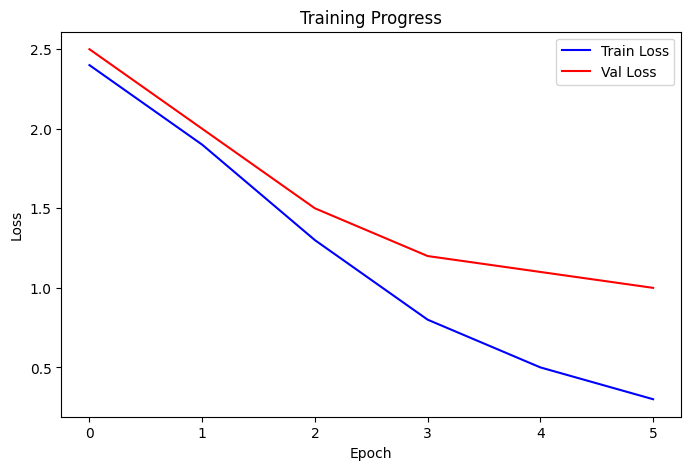

In [ ]:
# Plot training and validation loss
import matplotlib.pyplot as plt

train_losses = [2.4, 1.9, 1.3, 0.8, 0.5, 0.3]
val_losses   = [2.5, 2.0, 1.5, 1.2, 1.1, 1.0]

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses,   label='Val Loss',   color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.show()


GOOD: both train and val loss decrease steadily together.

OVERFITTING: train loss keeps going down, val loss stops or goes UP.

UNDERFITTING: both losses are high and barely decrease.

SOLUTION to overfitting: more data, dropout, regularisation, smaller model.

SOLUTION to underfitting: bigger model, more epochs, more features.


plt.plot()      # training/validation loss curves

plt.scatter()   # visualising data clusters

plt.hist()      # checking feature distributions

plt.bar()       # comparing model accuracies

sns.heatmap()   # feature correlation before training

In [ ]:
# Histogram: visualise feature distribution
import matplotlib.pyplot as plt
import numpy as np

ages = np.random.normal(loc=35, scale=10, size=1000)

plt.figure(figsize=(7, 4))
plt.hist(ages, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()


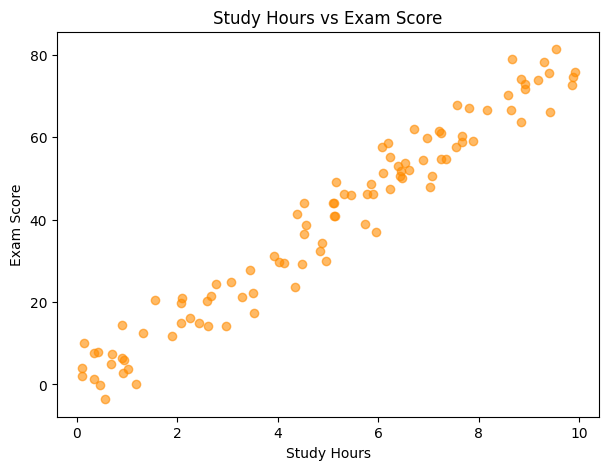

In [ ]:
# Scatter plot: does feature X predict target y?
import matplotlib.pyplot as plt
import numpy as np

study_hours = np.random.uniform(0, 10, 100)
scores = study_hours * 8 + np.random.normal(0, 5, 100)  # noisy relationship

plt.figure(figsize=(7, 5))
plt.scatter(study_hours, scores, alpha=0.6, color='darkorange')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')
plt.show()


other useful functions

In [ ]:
# Lambda: one-line throwaway functions
# Regular function
def square(x):
    return x ** 2

# Lambda equivalent (anonymous function)
square = lambda x: x ** 2

# Common in AI — applying transformations to data
import pandas as pd
df = pd.DataFrame({'price': [100, 200, 300]})

# Add a new column: price in thousands
df['price_k'] = df['price'].apply(lambda x: x / 1000)

print(df)


   price  price_k
0    100      0.1
1    200      0.2
2    300      0.3


In [ ]:
# try/except: handle errors gracefully
import torch

try:
    # Try to move model to GPU
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    print(f'Running on: {device}')
except RuntimeError as e:
    # If GPU out of memory, fall back to CPU
    print(f'GPU error: {e}. Switching to CPU.')
    device = 'cpu'
    model = model.to(device)


In [ ]:
  ▶  Reading and saving data files
import pandas as pd
import json
import os

# Save a DataFrame to CSV
df.to_csv('results.csv', index=False)

# Save a Python dict to JSON
config = {'lr': 0.001, 'epochs': 100}
with open('config.json', 'w') as f:
    json.dump(config, f)

# Load JSON back
with open('config.json', 'r') as f:
    loaded = json.load(f)

# Check if a file exists
if os.path.exists('model.pt'):
    model.load_state_dict(torch.load('model.pt'))


Complete workflow with python

In [ ]:
# Step 1: Load and explore
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

print(df.head())
print(df['species'].value_counts())  # Check class balance: 50 of each


In [ ]:
#  Step 2: Prepare features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('species', axis=1).values   # features as numpy array
y = df['species'].values                # labels

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)   # ONLY transform, no fit!


In [ ]:
# Step 3: Train and evaluate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=iris.target_names))


# LEC 4 Data Engineering AI

In [ ]:
# Extracting from different sources
import pandas as pd
import requests
import json

# From CSV file
df = pd.read_csv('data/customers.csv')

# From JSON file
df = pd.read_json('data/products.json')

# From a REST API
response = requests.get('https://api.example.com/data')
data = response.json()           # parse JSON response
df = pd.DataFrame(data['items']) # convert to DataFrame

# From SQL database
import sqlite3
conn = sqlite3.connect('database.db')
df = pd.read_sql('SELECT * FROM customers', conn)


In [ ]:
# Common transformations
import pandas as pd
import numpy as np

df = pd.read_csv('raw_data.csv')

# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['category'].fillna('Unknown', inplace=True)

# 3. Fix data types
df['date'] = pd.to_datetime(df['date'])
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 4. Create new features (feature engineering)
df['age_group'] = pd.cut(df['age'], bins=[0,25,45,65,100],
                         labels=['Young','Adult','Senior','Elder'])


errors='raise'   # default — crashes on "N/A" → your program dies

errors='coerce'  # silently converts bad values to NaN (empty)

errors='ignore'  # leaves bad values as-is (usually wrong choice)

In [ ]:
# Saving processed data
# Save to CSV (most portable)
df.to_csv('processed_data.csv', index=False)

# Save to Parquet (fast, compressed — preferred for large datasets)
df.to_parquet('processed_data.parquet')

# Save to SQLite database
import sqlite3
conn = sqlite3.connect('ai_data.db')
df.to_sql('training_data', conn, if_exists='replace', index=False)


# common options
df.to_csv('data.csv', index=False)                    # basic save

df.to_csv('data.csv', index=False, encoding='utf-8') # handle special characters

df.to_csv('data.csv', index=False, sep='\t')         # tab-separated instead of comma


In [ ]:
# Detecting outliers with IQR method
import pandas as pd
import numpy as np

# IQR = Interquartile Range method (robust to extreme outliers)
Q1 = df['salary'].quantile(0.25)  # 25th percentile
Q3 = df['salary'].quantile(0.75)  # 75th percentile
IQR = Q3 - Q1

# Outlier bounds: 1.5× IQR above/below Q1/Q3
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Keep only non-outlier rows
df_clean = df[(df['salary'] >= lower) & (df['salary'] <= upper)]
print(f'Removed {len(df) - len(df_clean)} outlier rows')


In [ ]:
# Fix inconsistent text data
import pandas as pd

df = pd.DataFrame({'gender': ['Male', 'male', 'M', 'Female', 'F', 'female']})

# Method 1: map to standard values
gender_map = {'Male':'M', 'male':'M', 'M':'M',
              'Female':'F', 'female':'F', 'F':'F'}
df['gender'] = df['gender'].map(gender_map)

# Method 2: lowercase then replace
df['gender'] = df['gender'].str.lower().str.strip()
df['gender'] = df['gender'].replace({'m':'male', 'f':'female'})


The pipeline: Raw text → Clean → Tokenise → Encode → Model

In [ ]:
# Clean raw text
import re

def clean_text(text):
    text = text.lower()                        # lowercase
    text = re.sub(r'http\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)          # remove @mentions
    text = re.sub(r'[^a-z0-9\s]', '', text)  # remove special chars
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

raw = 'Check out https://example.com! @AI is AMAZING!!! 🚀'
print(clean_text(raw))


In [ ]:
# Tokenisation with NLTK (word-level)
import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize

text = 'Machine learning transforms how we process data.'
tokens = word_tokenize(text)
print(tokens)
# ['Machine', 'learning', 'transforms', 'how', 'we', 'process', 'data', '.']


In [ ]:
# Tokenisation with HuggingFace (subword — used in LLMs)
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('gpt2')

text = 'I love machine learning!'
tokens = tokenizer(text)

print('Token IDs:', tokens['input_ids'])
# [40, 1842, 4572, 4673, 0]  ← each word becomes a number

# Decode back to text
print(tokenizer.decode(tokens['input_ids']))


In [ ]:
 # removing stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
# stop_words = {'the', 'is', 'in', 'it', 'and', 'a', 'an', ...}

tokens = ['the', 'cat', 'is', 'sitting', 'on', 'the', 'mat']

# Remove stopwords
clean = [w for w in tokens if w not in stop_words]
print(clean)  # ['cat', 'sitting', 'mat']


In [ ]:
# Extract text from PDF
import pdfplumber

with pdfplumber.open('report.pdf') as pdf:
    full_text = ''
    for page in pdf.pages:
        full_text += page.extract_text() or ''

print(full_text[:500])  # first 500 characters


In [ ]:
# Extract text from a webpage
import requests
from bs4 import BeautifulSoup

url = 'https://en.wikipedia.org/wiki/Artificial_intelligence'
response = requests.get(url)

soup = BeautifulSoup(response.text, 'html.parser')

# Get all paragraph text
paragraphs = soup.find_all('p')
text = ' '.join([p.get_text() for p in paragraphs])
print(text[:500]


In [ ]:
# OCR with Tesseract and EasyOCR
# Method 1: Tesseract (traditional, fast)
import pytesseract
from PIL import Image

image = Image.open('invoice.jpg')
text = pytesseract.image_to_string(image)
print(text)

# Method 2: EasyOCR (deep learning-based, more accurate)
import easyocr
reader = easyocr.Reader(['en'])  # English
result = reader.readtext('invoice.jpg')
# result = [(bounding_box, text, confidence), ...]
for (_, text, confidence) in result:
    if confidence > 0.5:
        print(text)


In [ ]:
# Comprehensive data quality check
import pandas as pd
import numpy as np

def data_quality_report(df):
    print(f'Shape: {df.shape}')
    print(f'Duplicates: {df.duplicated().sum()}')
    print('\nMissing values:')
    missing = df.isnull().sum()
    print(missing[missing > 0])
    print('\nData types:')
    print(df.dtypes)
    print('\nNumeric stats:')
    print(df.describe())

data_quality_report(df)


In [ ]:
# SQL queries in Python
import sqlite3
import pandas as pd

conn = sqlite3.connect('company.db')

# Get average salary per department for employees over 25
query = '''
    SELECT department,
           AVG(salary)  AS avg_salary,
           COUNT(*)     AS employee_count
    FROM employees
    WHERE age > 25
    GROUP BY department
    ORDER BY avg_salary DESC
'''

result = pd.read_sql(query, conn)
print(result)


In [ ]:
# Anonymising sensitive data
import pandas as pd
import hashlib

df = pd.DataFrame({
    'name':  ['Sapana Pandey', 'Rishi Singh'],
    'email': ['sapana@gmail.com', 'rishi@gmail.com'],
    'age':   [28, 35],
    'income': [80000, 120000]
})

# Hash the email (irreversible — can't get original email back)
df['email_hash'] = df['email'].apply(
    lambda x: hashlib.sha256(x.encode()).hexdigest()[:12]
)

# Drop identifying columns
df_anon = df.drop(columns=['name', 'email'])
print(df_anon)
